![NVIDIA Logo](images/nvidia.png)

# Router Stages

In this notebook we introduce the `RouterStage` which can be used to route data to multiple downstream stages based on a data condition.

---

## Objectives

By the time you complete this notebook you will be able to:

- Integrate a `RouterStage` with a pipeline that will route messages based on a data condition
- Tagging a `ControlMessage` with route metadata to to enable custom SIMD per message.
- Create custom stages capable of process data once received from the router.

---

## Imports

In [1]:
import itertools
import logging
import typing

from IPython.display import Image

from morpheus.config import Config

from morpheus.pipeline import Pipeline
from morpheus.pipeline.execution_mode_mixins import GpuAndCpuMixin
from morpheus.pipeline.pass_thru_type_mixin import PassThruTypeMixin
from morpheus.pipeline.single_port_stage import SinglePortStage

from morpheus.pipeline.stage import Stage
from morpheus.pipeline.stage_schema import StageSchema

from morpheus.stages.general.monitor_stage import MonitorStage
from morpheus.stages.general.router_stage import RouterStage
from morpheus.stages.input.file_source_stage import FileSourceStage
from morpheus.stages.output.in_memory_sink_stage import InMemorySinkStage
from morpheus.stages.preprocess.deserialize_stage import DeserializeStage

from morpheus.messages import MessageMeta, ControlMessage

from morpheus.utils.logger import configure_logging, reset_logging

import mrc
import mrc.core.operators as ops
from mrc.core.node import Broadcast

---

## Create a Custom Stage that will Add a Metadata Tag to Facilitate Message Routing

Tag each message with metadata that will be used to route the data to the appropriate processing branch.

In [2]:
class RouteMetadataTaggerStage(PassThruTypeMixin, GpuAndCpuMixin, SinglePortStage):
    
    def __init__(self,
                 config: Config,
                 branch_keys: list[str],
                ):
        super().__init__(config)
        
        self._branch_route_cycle = itertools.cycle(branch_keys)

    @property
    def name(self) -> str:
        return "add-route-metadata"

    # Note that this custom stage expects message type `ControlMessage`.
    def accepted_types(self) -> tuple:
        return (ControlMessage, )

    def supports_cpp_node(self) -> bool:
        return False

    # Tag the `ControlMessage` metadata with the branch that should process this message.
    def on_data(self, message: ControlMessage) -> ControlMessage:
        message.set_metadata("route", next(self._branch_route_cycle))
        return message

    def _build_single(self, builder: mrc.Builder, input_node: mrc.SegmentObject) -> mrc.SegmentObject:
        node = builder.make_node(self.unique_name, ops.map(self.on_data))
        builder.make_edge(input_node, node)

        return node

---

## Create a Custom Stage that will Process Messages in a Branch

This stage will perform some notional work on incoming data, adding a column represent the branch that received the data.

In [3]:
class SimpleBranchWorkerStage(PassThruTypeMixin, GpuAndCpuMixin, SinglePortStage):
    
    def __init__(self,
                 config: Config,
                 branch_id: int,
                ):
        super().__init__(config)
        
        self._branch_id = branch_id

    @property
    def name(self) -> str:
        return f"single-branch-worker-{self._branch_id}"

    # Note that this custom stage expects message type `ControlMessage`.
    def accepted_types(self) -> tuple:
        return (ControlMessage, )

    def supports_cpp_node(self) -> bool:
        return False

    def on_data(self, message: ControlMessage) -> ControlMessage:
        # Tag each message with the branch ID that is processing this message
        with message.payload().mutable_dataframe() as mdf:
            mdf["processing_branch"] = self._branch_id
        return message

    def _build_single(self, builder: mrc.Builder, input_node: mrc.SegmentObject) -> mrc.SegmentObject:
        node = builder.make_node(self.unique_name, ops.map(self.on_data))
        builder.make_edge(input_node, node)

        return node    

## Define the Router's Key Funtion

## Define the Router's Key Function

This function will be used by the router stage to determine which processing path to send the data. Our `router_key_fn` function will consider the tagged metadata to inform its routing decision.

In [4]:
def router_key_fn(msg: ControlMessage):
    return msg.get_metadata("route")

## Build Pipeline Using Custom Stage

Build a pipeline using the components to demonstrate the utility of the Morpheus `RouterStage`.

In [5]:
input_file = 'data/simple_user_log.jsonlines'

config = Config()

pipeline = Pipeline(config)

branch_keys=["route_a","route_b"]

source = pipeline.add_stage(FileSourceStage(config, filename=input_file, iterative=False, repeat=100))
deserialize = pipeline.add_stage(DeserializeStage(config))
metadata_tagger = pipeline.add_stage(RouteMetadataTaggerStage(config, branch_keys=branch_keys))
router = pipeline.add_stage(RouterStage(config, keys=branch_keys, key_fn=router_key_fn))

route_a = pipeline.add_stage(SimpleBranchWorkerStage(config, branch_id="route_a"))
in_mem_sink1 = pipeline.add_stage(InMemorySinkStage(config))

route_b = pipeline.add_stage(SimpleBranchWorkerStage(config, branch_id="route_b"))
in_mem_sink2 = pipeline.add_stage(InMemorySinkStage(config))

# connect the stages together
pipeline.add_edge(source, deserialize)
pipeline.add_edge(deserialize, metadata_tagger)
pipeline.add_edge(metadata_tagger, router)
pipeline.add_edge(router.output_ports[0], route_a)
pipeline.add_edge(router.output_ports[1], route_b)
pipeline.add_edge(route_a, in_mem_sink1)
pipeline.add_edge(route_b, in_mem_sink2)

pipeline.build()

---

## Run the Pipeline

In [6]:
viz_file = './pipeline_visualizations/router_pipeline.png'
pipeline.visualize(viz_file)

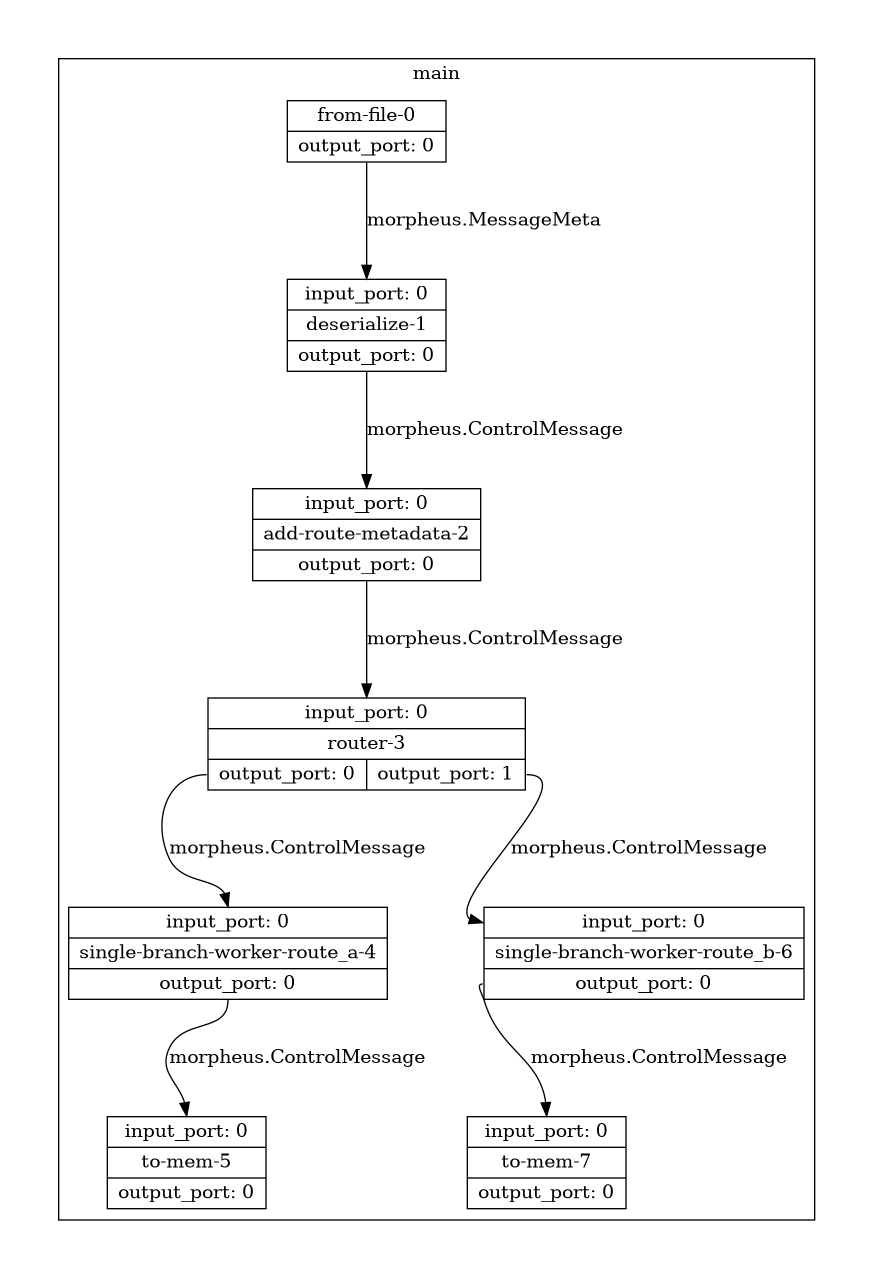

In [7]:
Image(filename=viz_file)

In [8]:
reset_logging()
configure_logging(log_level=logging.DEBUG)

====Starting Pipeline====
====Pipeline Started====
====Building Segment: main====
Added source: <from-file-0; FileSourceStage(filename=data/simple_user_log.jsonlines, iterative=False, file_type=FileTypes.Auto, repeat=100, filter_null=True, filter_null_columns=None, parser_kwargs=None)>
  └─> morpheus.MessageMeta
Added stage: <deserialize-1; DeserializeStage(ensure_sliceable_index=True, task_type=None, task_payload=None)>
  └─ morpheus.MessageMeta -> morpheus.ControlMessage
Added stage: <add-route-metadata-2; RouteMetadataTaggerStage(branch_keys=['route_a', 'route_b'])>
  └─ morpheus.ControlMessage -> morpheus.ControlMessage
Added stage: <single-branch-worker-route_a-4; SimpleBranchWorkerStage(branch_id=route_a)>
  └─ morpheus.ControlMessage -> morpheus.ControlMessage
Added stage: <to-mem-5; InMemorySinkStage()>
  └─ morpheus.ControlMessage -> morpheus.ControlMessage
Added stage: <single-branch-worker-route_b-6; SimpleBranchWorkerStage(branch_id=route_b)>
  └─ morpheus.ControlMessage ->

In [9]:
await pipeline.run_async()

This sink's output will show all messages have been processed by `route_a`.

In [10]:
messages = in_mem_sink1.get_messages()
messages[0].payload().get_data()

,timestamp,user,ip_address,request_time,status,error_message,processing_branch
0,2025-02-01T10:15:30Z,user123,192.168.1.10,200.45,success,<NA>,route_a
1,2025-02-01T10:17:00Z,user123,192.168.1.20,150.55,failure,Invalid credentials,route_a
2,2025-02-01T10:18:10Z,user456,10.0.0.5,180.60,success,<NA>,route_a
3,2025-02-01T10:19:25Z,user789,192.168.1.30,215.25,failure,Timeout,route_a
4,2025-02-01T10:20:00Z,user456,10.0.0.6,120.10,success,<NA>,route_a
5,2025-02-01T10:22:30Z,user123,192.168.1.40,175.35,failure,Access denied,route_a
6,2025-02-01T10:23:45Z,user321,192.168.1.50,205.50,success,<NA>,route_a
7,2025-02-01T10:25:05Z,user864,192.168.1.60,190.15,failure,Invalid session,route_a
8,2025-02-01T10:26:20Z,user123,192.168.1.70,210.80,success,<NA>,route_a
9,2025-02-01T10:27:40Z,user456,10.0.0.7,160.95,failure,Account locked,route_a


This sink's output will show all messages have been processed by `route_b`.

In [11]:
messages = in_mem_sink2.get_messages()
messages[0].payload().get_data()

,timestamp,user,ip_address,request_time,status,error_message,processing_branch
10,2025-02-01T10:15:30Z,user123,192.168.1.10,200.45,success,<NA>,route_b
11,2025-02-01T10:17:00Z,user123,192.168.1.20,150.55,failure,Invalid credentials,route_b
12,2025-02-01T10:18:10Z,user456,10.0.0.5,180.60,success,<NA>,route_b
13,2025-02-01T10:19:25Z,user789,192.168.1.30,215.25,failure,Timeout,route_b
14,2025-02-01T10:20:00Z,user456,10.0.0.6,120.10,success,<NA>,route_b
15,2025-02-01T10:22:30Z,user123,192.168.1.40,175.35,failure,Access denied,route_b
16,2025-02-01T10:23:45Z,user321,192.168.1.50,205.50,success,<NA>,route_b
17,2025-02-01T10:25:05Z,user864,192.168.1.60,190.15,failure,Invalid session,route_b
18,2025-02-01T10:26:20Z,user123,192.168.1.70,210.80,success,<NA>,route_b
19,2025-02-01T10:27:40Z,user456,10.0.0.7,160.95,failure,Account locked,route_b
